# **Project Name**    - Tesla Stock Price Prediction


##### **Project Type**    - Deep Learning / Time Series Forecasting
##### **Contribution**    - Individual
Name: Aditi Soni


# **Project Summary -**

The Tesla Stock Price Prediction project aims to forecast future closing prices of Tesla stock using Deep Learning techniques and historical stock market data. Stock price prediction is a challenging time-series forecasting problem because market prices are influenced by various factors such as investor sentiment, company performance, economic conditions, and market trends. In this project, historical Tesla stock data containing features such as Date, Open, High, Low, Close, Adjusted Close, and Volume was analyzed to understand stock movement patterns over time. The dataset was preprocessed by handling missing values, converting date information into a suitable format, and selecting the closing price as the target variable for prediction. Data normalization was performed using MinMaxScaler to improve model convergence and training efficiency.

Exploratory Data Analysis (EDA) was conducted to identify trends, fluctuations, and overall behavior of Tesla's stock price. Various visualizations were created to analyze the closing price trend and trading volume across different time periods. Since stock market data is sequential in nature, Recurrent Neural Networks (RNNs) are well suited for capturing temporal dependencies. Therefore, two deep learning architectures, namely SimpleRNN and Long Short-Term Memory (LSTM), were implemented and compared. Time-series sequences were generated using a rolling window approach, where the previous 60 days of stock prices were used to predict future values. The models were trained to forecast Tesla's stock closing price for 1-day, 5-day, and 10-day horizons, allowing a comparison of short-term and relatively longer-term prediction capabilities.

The performance of both models was evaluated using standard regression metrics such as Mean Squared Error (MSE), Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE). Actual and predicted stock prices were visualized to assess how effectively each model captured market trends and price movements. The results demonstrated the ability of deep learning models, particularly LSTM networks, to learn complex sequential patterns from financial time-series data. Finally, the trained model was integrated into an interactive Streamlit web application where users can upload Tesla stock data, visualize trends, and generate future stock price predictions. This end-to-end implementation showcases the practical application of deep learning, time-series forecasting, data visualization, and model deployment in the financial domain.



# **GitHub Link -**

https://github.com/Aditi-12-soni/Tesla_Stock_Price_Prediction

# **Problem Statement**

The objective of this project is to predict Tesla's future stock closing prices using Deep Learning techniques. Historical Tesla stock data is analyzed and preprocessed to build SimpleRNN and LSTM models capable of forecasting stock prices for 1-day, 5-day, and 10-day prediction horizons. The performance of both models is evaluated and compared using standard metrics such as MSE, MAE, and RMSE to identify the most effective approach for stock price forecasting, and the final solution is deployed through a Streamlit web application.


In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# Preprocessing and evaluation
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# TensorFlow / Keras
import tensorflow as tf

Sequential = tf.keras.models.Sequential
SimpleRNN = tf.keras.layers.SimpleRNN
LSTM = tf.keras.layers.LSTM
Dense = tf.keras.layers.Dense
Dropout = tf.keras.layers.Dropout
EarlyStopping = tf.keras.callbacks.EarlyStopping

In [ ]:
# Load dataset
# Change filename if your file name is different

df = pd.read_csv("TSLA.csv")

# Show first 5 rows
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [ ]:
# Check dataset shape
print("Dataset Shape:", df.shape)

# Check column names and data types
df.info()

# Statistical summary
df.describe()

Dataset Shape: (2416, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


In [ ]:
# Check missing values in each column

df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [ ]:
# For time-series data, we use forward fill
# It fills missing values using previous available value

df = df.ffill()

# Check missing values again
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [ ]:
# Convert Date column to datetime format

df['Date'] = pd.to_datetime(df['Date'])

# Sort data by date
df = df.sort_values('Date')

# Set Date column as index
df.set_index('Date', inplace=True)

# Display updated dataset
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


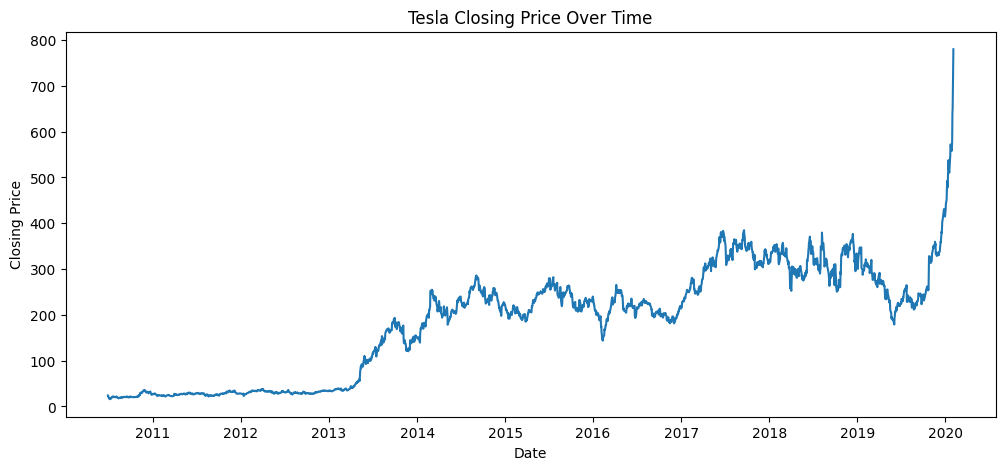

In [ ]:
# Plot Tesla closing price

plt.figure(figsize=(12,5))
plt.plot(df['Close'])
plt.title("Tesla Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

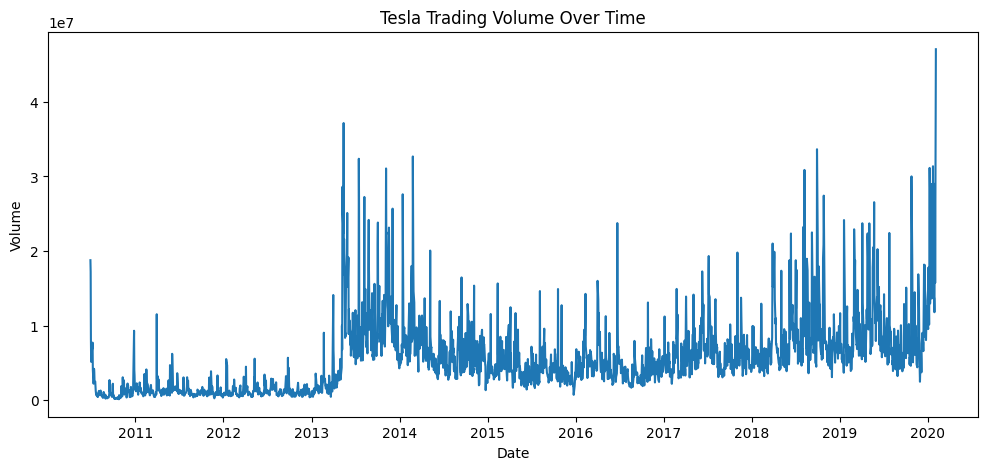

In [ ]:
# Plot Tesla trading volume

plt.figure(figsize=(12,5))
plt.plot(df['Volume'])
plt.title("Tesla Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

In [ ]:
# We are using only Closing Price for prediction

data = df[['Close']]

data.head()

,Close
Date,
2010-06-29,23.889999
2010-06-30,23.830000
2010-07-01,21.959999
2010-07-02,19.200001
2010-07-06,16.110001


In [ ]:
# Scale values between 0 and 1

scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(data)

scaled_data[:5]

array([[0.01058623],
       [0.01050772],
       [0.00806072],
       [0.0044491 ],
       [0.00040565]])

In [ ]:
# Split data into 80% training and 20% testing
# We do not shuffle time-series data

train_size = int(len(scaled_data) * 0.8)

train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

print("Training Data Shape:", train_data.shape)
print("Testing Data Shape:", test_data.shape)

Training Data Shape: (1932, 1)
Testing Data Shape: (484, 1)


In [ ]:
# This function creates time-series sequences
# window_size = past number of days used for prediction
# forecast_days = how many days ahead we want to predict

def create_sequences(dataset, window_size=60, forecast_days=1):
    X = []
    y = []

    for i in range(window_size, len(dataset) - forecast_days + 1):
        X.append(dataset[i-window_size:i, 0])
        y.append(dataset[i + forecast_days - 1, 0])

    X = np.array(X)
    y = np.array(y)

    # Reshape X for RNN/LSTM: samples, time steps, features
    X = X.reshape(X.shape[0], X.shape[1], 1)

    return X, y

In [ ]:
# Function to build SimpleRNN model

def build_simple_rnn(input_shape):
    model = Sequential()

    model.add(SimpleRNN(50, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mean_squared_error'
    )

    return model

In [ ]:
# Function to build LSTM model

def build_lstm(input_shape):
    model = Sequential()

    model.add(LSTM(50, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mean_squared_error'
    )

    return model

In [ ]:
# Function to evaluate model performance

def evaluate_model(model, X_test, y_test, scaler):
    predictions = model.predict(X_test)

    # Convert scaled values back to original price
    predictions = scaler.inverse_transform(predictions)
    actual = scaler.inverse_transform(y_test.reshape(-1, 1))

    mse = mean_squared_error(actual, predictions)
    mae = mean_absolute_error(actual, predictions)
    rmse = math.sqrt(mse)

    return actual, predictions, mse, mae, rmse

In [ ]:
# Early stopping prevents overfitting

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
window_size = 60
forecast_days = 1

X_train_1, y_train_1 = create_sequences(train_data, window_size, forecast_days)
X_test_1, y_test_1 = create_sequences(test_data, window_size, forecast_days)

print("X_train_1:", X_train_1.shape)
print("y_train_1:", y_train_1.shape)
print("X_test_1:", X_test_1.shape)
print("y_test_1:", y_test_1.shape)

X_train_1: (1872, 60, 1)
y_train_1: (1872,)
X_test_1: (424, 60, 1)
y_test_1: (424,)


In [ ]:
# Build SimpleRNN model for 1-day prediction

rnn_1 = build_simple_rnn((X_train_1.shape[1], 1))

# Train model
history_rnn_1 = rnn_1.fit(
    X_train_1,
    y_train_1,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0091 - val_loss: 0.0041
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0022 - val_loss: 0.0019
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0016 - val_loss: 0.0020
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0011 - val_loss: 0.0021
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.8706e-04 - val_loss: 8.9017e-04
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.3489e-04 - val_loss: 6.8253e-04
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.4032e-04 - val_loss: 5.4763e-04
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.7861e-04 - val_loss: 6.1759e-04
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 6.0558e-04 - val_loss: 7.9266e-04
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.3481e-04 - val_loss: 6.7412e-04
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.2560e-04 - val_loss: 4.3912e-04
Epoch 12/20
53/53 ━━━━━━━

In [ ]:
# Build LSTM model for 1-day prediction

lstm_1 = build_lstm((X_train_1.shape[1], 1))

# Train model
history_lstm_1 = lstm_1.fit(
    X_train_1,
    y_train_1,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0060 - val_loss: 5.2517e-04
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 6.1767e-04 - val_loss: 4.8037e-04
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 5.7577e-04 - val_loss: 4.4275e-04
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 4.7274e-04 - val_loss: 5.4897e-04
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 4.3241e-04 - val_loss: 4.3539e-04


In [ ]:
# Evaluate SimpleRNN

actual_1, pred_rnn_1, mse_rnn_1, mae_rnn_1, rmse_rnn_1 = evaluate_model(
    rnn_1, X_test_1, y_test_1, scaler
)

# Evaluate LSTM

actual_1, pred_lstm_1, mse_lstm_1, mae_lstm_1, rmse_lstm_1 = evaluate_model(
    lstm_1, X_test_1, y_test_1, scaler
)

print("SimpleRNN 1-Day MSE:", mse_rnn_1)
print("SimpleRNN 1-Day MAE:", mae_rnn_1)
print("SimpleRNN 1-Day RMSE:", rmse_rnn_1)

print("LSTM 1-Day MSE:", mse_lstm_1)
print("LSTM 1-Day MAE:", mae_lstm_1)
print("LSTM 1-Day RMSE:", rmse_lstm_1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
SimpleRNN 1-Day MSE: 420.3490153581345
SimpleRNN 1-Day MAE: 14.296301267916698
SimpleRNN 1-Day RMSE: 20.502414866501326
LSTM 1-Day MSE: 609.928310434209
LSTM 1-Day MAE: 18.53623723543448
LSTM 1-Day RMSE: 24.696726714975995


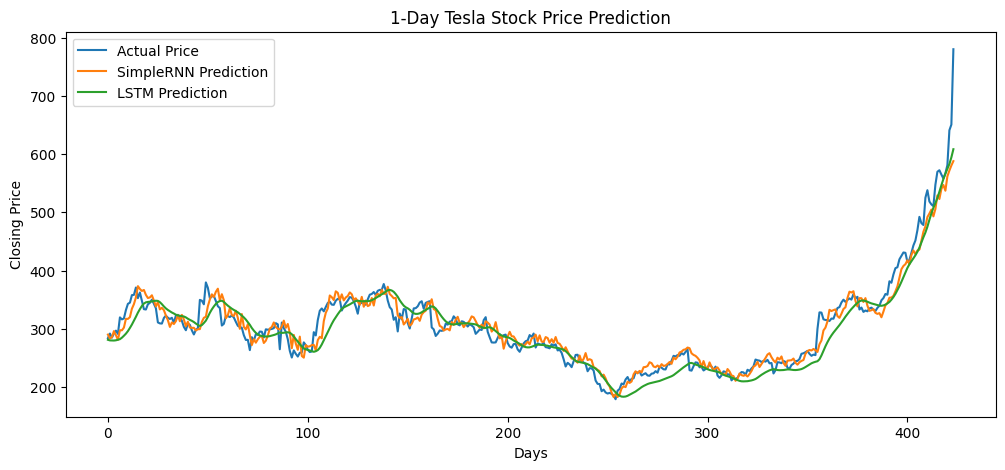

In [ ]:
# Plot 1-day prediction
plt.figure(figsize=(12,5))
plt.plot(actual_1, label="Actual Price")
plt.plot(pred_rnn_1, label="SimpleRNN Prediction")
plt.plot(pred_lstm_1, label="LSTM Prediction")
plt.title("1-Day Tesla Stock Price Prediction")
plt.xlabel("Days")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

In [ ]:
#Create data for 5-day prediction
forecast_days = 5

X_train_5, y_train_5 = create_sequences(train_data, window_size, forecast_days)
X_test_5, y_test_5 = create_sequences(test_data, window_size, forecast_days)

print("X_train_5:", X_train_5.shape)
print("y_train_5:", y_train_5.shape)
print("X_test_5:", X_test_5.shape)
print("y_test_5:", y_test_5.shape)

X_train_5: (1868, 60, 1)
y_train_5: (1868,)
X_test_5: (420, 60, 1)
y_test_5: (420,)


In [ ]:
#Train SimpleRNN for 5 days
rnn_5 = build_simple_rnn((X_train_5.shape[1], 1))

history_rnn_5 = rnn_5.fit(
    X_train_5,
    y_train_5,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0019 - val_loss: 0.0013
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.3641e-04 - val_loss: 0.0019
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.2983e-04 - val_loss: 7.6668e-04
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.4700e-04 - val_loss: 9.0498e-04
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6.2858e-04 - val_loss: 8.8393e-04


In [ ]:
#Train LSTM for 5 days
lstm_5 = build_lstm((X_train_5.shape[1], 1))

history_lstm_5 = lstm_5.fit(
    X_train_5,
    y_train_5,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0071 - val_loss: 0.0012
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 8.2252e-04 - val_loss: 0.0017
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 7.4424e-04 - val_loss: 9.4867e-04
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 7.2524e-04 - val_loss: 0.0011
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 6.6077e-04 - val_loss: 8.4404e-04


In [ ]:
#Evaluate 5-day models
actual_5, pred_rnn_5, mse_rnn_5, mae_rnn_5, rmse_rnn_5 = evaluate_model(
    rnn_5, X_test_5, y_test_5, scaler
)

actual_5, pred_lstm_5, mse_lstm_5, mae_lstm_5, rmse_lstm_5 = evaluate_model(
    lstm_5, X_test_5, y_test_5, scaler
)

print("SimpleRNN 5-Day MSE:", mse_rnn_5)
print("SimpleRNN 5-Day MAE:", mae_rnn_5)
print("SimpleRNN 5-Day RMSE:", rmse_rnn_5)

print("LSTM 5-Day MSE:", mse_lstm_5)
print("LSTM 5-Day MAE:", mae_lstm_5)
print("LSTM 5-Day RMSE:", rmse_lstm_5)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
SimpleRNN 5-Day MSE: 1787.8647688653386
SimpleRNN 5-Day MAE: 27.903608517536277
SimpleRNN 5-Day RMSE: 42.28314994019886
LSTM 5-Day MSE: 1804.8785052448916
LSTM 5-Day MAE: 30.518470305333892
LSTM 5-Day RMSE: 42.48386170353269


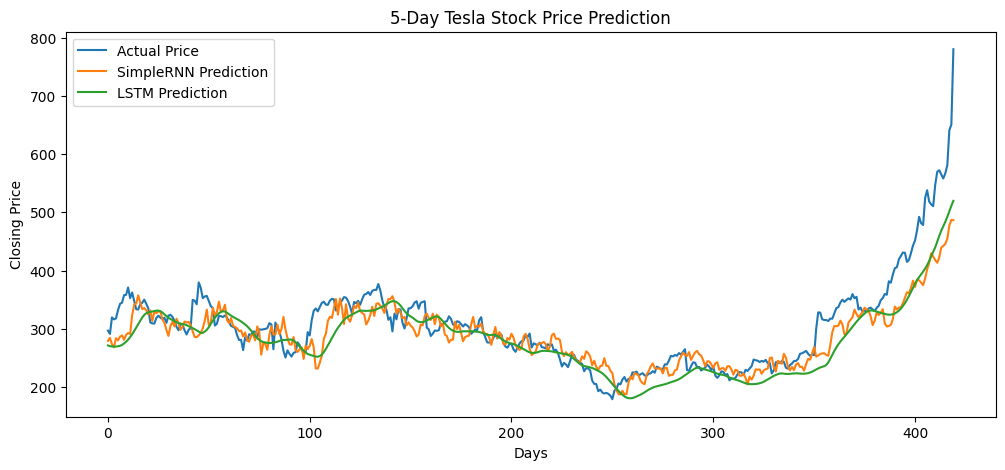

In [ ]:
#Plot 5-day prediction
plt.figure(figsize=(12,5))
plt.plot(actual_5, label="Actual Price")
plt.plot(pred_rnn_5, label="SimpleRNN Prediction")
plt.plot(pred_lstm_5, label="LSTM Prediction")
plt.title("5-Day Tesla Stock Price Prediction")
plt.xlabel("Days")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

In [ ]:
#Create data for 10-day prediction
forecast_days = 10

X_train_10, y_train_10 = create_sequences(train_data, window_size, forecast_days)
X_test_10, y_test_10 = create_sequences(test_data, window_size, forecast_days)

print("X_train_10:", X_train_10.shape)
print("y_train_10:", y_train_10.shape)
print("X_test_10:", X_test_10.shape)
print("y_test_10:", y_test_10.shape)

X_train_10: (1863, 60, 1)
y_train_10: (1863,)
X_test_10: (415, 60, 1)
y_test_10: (415,)


In [ ]:
#Train SimpleRNN for 10 days
rnn_10 = build_simple_rnn((X_train_10.shape[1], 1))

history_rnn_10 = rnn_10.fit(
    X_train_10,
    y_train_10,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0027 - val_loss: 0.0037
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0010 - val_loss: 0.0011
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.3773e-04 - val_loss: 0.0035
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.3097e-04 - val_loss: 0.0012
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.7636e-04 - val_loss: 0.0016


In [ ]:
#Train LSTM for 10 days
lstm_10 = build_lstm((X_train_10.shape[1], 1))

history_lstm_10 = lstm_10.fit(
    X_train_10,
    y_train_10,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0060 - val_loss: 0.0012
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9.0842e-04 - val_loss: 0.0011
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.7999e-04 - val_loss: 0.0011
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 7.8006e-04 - val_loss: 0.0012
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.7639e-04 - val_loss: 0.0012


In [ ]:
#Evaluate 10-day models
actual_10, pred_rnn_10, mse_rnn_10, mae_rnn_10, rmse_rnn_10 = evaluate_model(
    rnn_10, X_test_10, y_test_10, scaler
)

actual_10, pred_lstm_10, mse_lstm_10, mae_lstm_10, rmse_lstm_10 = evaluate_model(
    lstm_10, X_test_10, y_test_10, scaler
)

print("SimpleRNN 10-Day MSE:", mse_rnn_10)
print("SimpleRNN 10-Day MAE:", mae_rnn_10)
print("SimpleRNN 10-Day RMSE:", rmse_rnn_10)

print("LSTM 10-Day MSE:", mse_lstm_10)
print("LSTM 10-Day MAE:", mae_lstm_10)
print("LSTM 10-Day RMSE:", rmse_lstm_10)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
SimpleRNN 10-Day MSE: 3273.0033412661246
SimpleRNN 10-Day MAE: 39.52841858777767
SimpleRNN 10-Day RMSE: 57.210168163239345
LSTM 10-Day MSE: 2024.3063028865758
LSTM 10-Day MAE: 33.23920204930346
LSTM 10-Day RMSE: 44.99229159407838


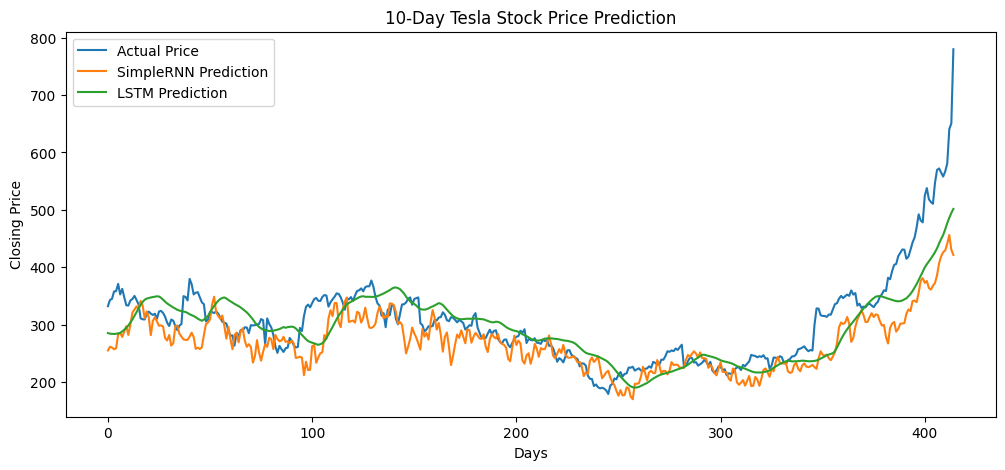

In [ ]:
#Plot 10-day prediction
plt.figure(figsize=(12,5))
plt.plot(actual_10, label="Actual Price")
plt.plot(pred_rnn_10, label="SimpleRNN Prediction")
plt.plot(pred_lstm_10, label="LSTM Prediction")
plt.title("10-Day Tesla Stock Price Prediction")
plt.xlabel("Days")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

In [ ]:
# Compare all model performances

results = pd.DataFrame({
    "Forecast": [
        "1 Day", "1 Day",
        "5 Days", "5 Days",
        "10 Days", "10 Days"
    ],
    "Model": [
        "SimpleRNN", "LSTM",
        "SimpleRNN", "LSTM",
        "SimpleRNN", "LSTM"
    ],
    "MSE": [
        mse_rnn_1, mse_lstm_1,
        mse_rnn_5, mse_lstm_5,
        mse_rnn_10, mse_lstm_10
    ],
    "MAE": [
        mae_rnn_1, mae_lstm_1,
        mae_rnn_5, mae_lstm_5,
        mae_rnn_10, mae_lstm_10
    ],
    "RMSE": [
        rmse_rnn_1, rmse_lstm_1,
        rmse_rnn_5, rmse_lstm_5,
        rmse_rnn_10, rmse_lstm_10
    ]
})

results

,Forecast,Model,MSE,MAE,RMSE
0,1 Day,SimpleRNN,420.349015,14.296301,20.502415
1,1 Day,LSTM,609.928310,18.536237,24.696727
2,5 Days,SimpleRNN,1787.864769,27.903609,42.283150
3,5 Days,LSTM,1804.878505,30.518470,42.483862
4,10 Days,SimpleRNN,3273.003341,39.528419,57.210168
5,10 Days,LSTM,2024.306303,33.239202,44.992292


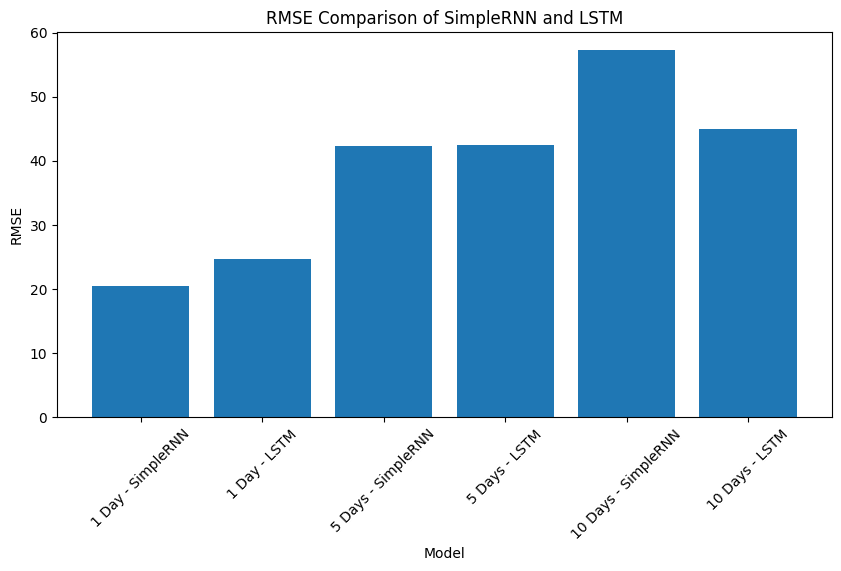

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(results["Forecast"] + " - " + results["Model"], results["RMSE"])
plt.title("RMSE Comparison of SimpleRNN and LSTM")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Save model in modern Keras format

lstm_1.save("tesla_lstm_model.keras")

In [ ]:
# Save scaler for later use in Streamlit app

import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
# Import files module
from google.colab import files

# Check available files
import os
print("Files present:")
print(os.listdir())

# Download model
files.download("tesla_lstm_model.keras")

# Download scaler
files.download("scaler.pkl")

Files present:
['.config', 'scaler.pkl', 'TSLA.csv', 'tesla_lstm_model.keras', 'sample_data']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

In this project, Tesla stock closing price was predicted using SimpleRNN and LSTM deep learning models.

The dataset was cleaned, missing values were handled using forward fill, and the closing price was scaled using MinMaxScaler. Time-series sequences were created using the past 60 days of closing price data.

Both SimpleRNN and LSTM models were trained for 1-day, 5-day, and 10-day stock price prediction. Their performance was compared using MSE, MAE, and RMSE.

LSTM is generally better for stock price prediction because it can remember long-term dependencies better than SimpleRNN.

## Future Scope

The project can be improved by adding:
- News sentiment analysis
- Trading volume trends
- Technical indicators
- Macroeconomic indicators
- GRU or Transformer models